# Assignment 4 – Pokemon Analysis

Full solution covering the five tasks from `ue4.pdf`:
1. Distance function & pairwise distance matrix
2. Clustering (with silhouette justification)
3. 2D visualization with t-SNE and UMAP
4. Outlier detection (LOF, Isolation Forest, HDBSCAN noise)
5. Discussion & reflection

In [35]:
!pip install -q numpy pandas scikit-learn matplotlib seaborn umap-learn hdbscan jupyter ipywidgets


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

import umap
import hdbscan

RNG = 42
sns.set_style("whitegrid")

## 1. Distance Function

**Idea:** A Pokemon's identity is defined mainly by its **battle stats** and its **types**. We combine both:

- 6 battle stats (`HP`, `attack`, `defense`, `sp. attack`, `sp. defense`, `speed`) → standardized so each contributes equally.
- 17 type one-hot columns → kept as-is (binary).
- Stat block weighted slightly higher than the type block (`w_stats = 1.5`, `w_types = 1.0`) so two Pokemon with the same type but very different stats still end up apart.

**Distance metric:** Euclidean in this combined space (concrete, well-behaved, supported by every clustering / outlier method we use).

In [37]:
df = pd.read_csv("pokedex.csv")
print(df.shape)
df.head()

(898, 31)


,id,name,HP,attack,defense,sp. attack,sp. defense,speed,species,description,...,type_ground,type_flying,type_psychic,type_bug,type_rock,type_ghost,type_dragon,type_dark,type_steel,type_fairy
0,1,Bulbasaur,45,49,49,65,65,45,Seed Pokémon,Bulbasaur can be seen napping in bright sunlig...,...,0,0,0,0,0,0,0,0,0,0
1,2,Ivysaur,60,62,63,80,80,60,Seed Pokémon,There is a bud on this Pokémon’s back. To supp...,...,0,0,0,0,0,0,0,0,0,0
2,3,Venusaur,80,82,83,100,100,80,Seed Pokémon,There is a large flower on Venusaur’s back. Th...,...,0,0,0,0,0,0,0,0,0,0
3,4,Charmander,39,52,43,60,50,65,Lizard Pokémon,The flame that burns at the tip of its tail is...,...,0,0,0,0,0,0,0,0,0,0
4,5,Charmeleon,58,64,58,80,65,80,Flame Pokémon,Charmeleon mercilessly destroys its foes using...,...,0,0,0,0,0,0,0,0,0,0


In [38]:
stat_cols = ["HP", "attack", "defense", "sp. attack", "sp. defense", "speed"]
type_cols = [c for c in df.columns if c.startswith("type_")]

stats_scaled = StandardScaler().fit_transform(df[stat_cols])
types = df[type_cols].to_numpy(dtype=float)

W_STATS, W_TYPES = 1.5, 1.0
X = np.hstack([W_STATS * stats_scaled, W_TYPES * types])

primary_type = df[type_cols].idxmax(axis=1).str.replace("type_", "", regex=False)
df["primary_type"] = primary_type

print("Feature matrix:", X.shape)

Feature matrix: (898, 23)


In [ ]:
distance = pairwise_distances(X, metric="euclidean")
dist_df = pd.DataFrame(distance, index=df["name"], columns=df["name"])

print(f"Shape: {dist_df.shape}")
print(f"Symmetric: {np.allclose(distance, distance.T)}")
print(f"Diagonal ~0: {np.allclose(np.diag(distance), 0, atol=1e-10)}")
print(f"Range: [{distance.min():.3f}, {distance.max():.3f}]")

# HDBSCAN directly on the precomputed distance matrix
hdb_dist = hdbscan.HDBSCAN(
    metric="precomputed",
    min_cluster_size=10,
    min_samples=5,
).fit(distance.astype(np.float64))
df["hdb_cluster"] = hdb_dist.labels_

n_clusters = (hdb_dist.labels_.max() + 1) if hdb_dist.labels_.max() >= 0 else 0
n_noise = int((hdb_dist.labels_ == -1).sum())
print(f"\nHDBSCAN on distance matrix → {n_clusters} clusters, {n_noise} noise points")
print(pd.Series(hdb_dist.labels_).value_counts().sort_index())

dist_df.iloc[:8, :8].round(2)

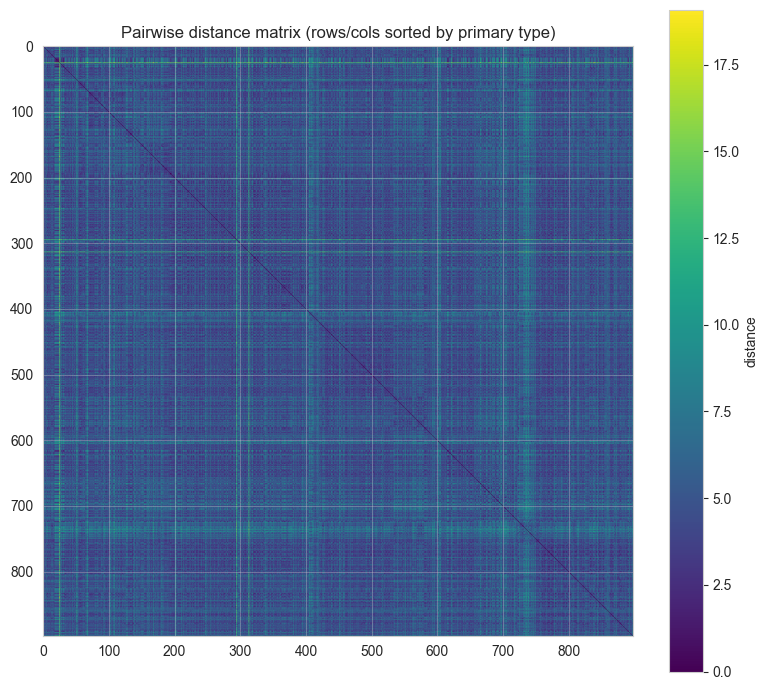

In [40]:
order = primary_type.sort_values().index.to_numpy()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(distance[np.ix_(order, order)], cmap="viridis")
ax.set_title("Pairwise distance matrix (rows/cols sorted by primary type)")
plt.colorbar(im, ax=ax, label="distance")
plt.tight_layout(); plt.show()

## 2. Clustering

We try **KMeans** and **Agglomerative (Ward)** for `k = 2..15` and pick the `k` with the highest **silhouette score** (computed on the same Euclidean feature space). Silhouette ∈ [-1, 1]; higher = denser, better-separated clusters.

In [41]:
ks = list(range(2, 16))
rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(X)
    ag = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X)
    rows.append({
        "k": k,
        "kmeans": silhouette_score(X, km.labels_),
        "agglomerative": silhouette_score(X, ag.labels_),
    })
scores = pd.DataFrame(rows).set_index("k")
scores

,kmeans,agglomerative
k,,
2,0.259889,0.241630
3,0.226842,0.181787
4,0.202115,0.186729
5,0.200191,0.187091
6,0.193766,0.190064
7,0.202674,0.116589
8,0.143465,0.119041
9,0.138623,0.119742
10,0.129680,0.112479


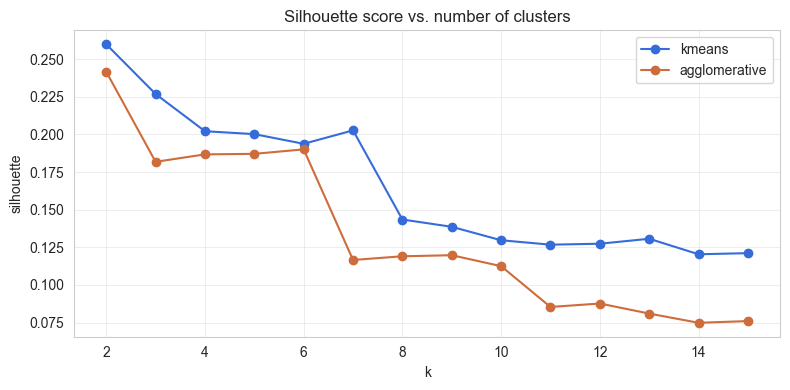

Best: kmeans with k=2 (silhouette=0.260)


In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
scores.plot(marker="o", ax=ax)
ax.set_xlabel("k"); ax.set_ylabel("silhouette")
ax.set_title("Silhouette score vs. number of clusters")
plt.tight_layout(); plt.show()

best_algo = scores.max().idxmax()
best_k = int(scores[best_algo].idxmax())
print(f"Best: {best_algo} with k={best_k} (silhouette={scores.loc[best_k, best_algo]:.3f})")

In [43]:
if best_algo == "kmeans":
    model = KMeans(n_clusters=best_k, n_init=10, random_state=RNG).fit(X)
else:
    model = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit(X)

df["cluster"] = model.labels_
df.groupby("cluster")[stat_cols].mean().round(1)

,HP,attack,defense,sp. attack,sp. defense,speed
cluster,,,,,,
0,51.1,55.4,52.8,50.7,50.7,52.0
1,82.4,92.3,86.1,83.8,84.2,76.2


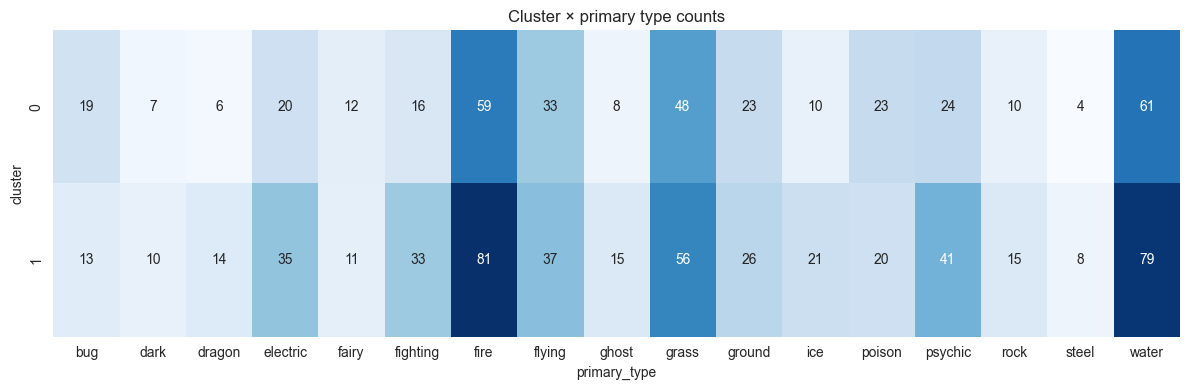

In [44]:
cross = pd.crosstab(df["cluster"], df["primary_type"])
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_title("Cluster × primary type counts")
plt.tight_layout(); plt.show()

## 3. Visualization (t-SNE & UMAP)

Projecting `X` into 2D with two non-linear methods. Both are colored by the cluster labels from task 2.

/Users/ericbuchinger/Library/CloudStorage/OneDrive-FHOOe/2. Semester/DAM2/Uebungen/04/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


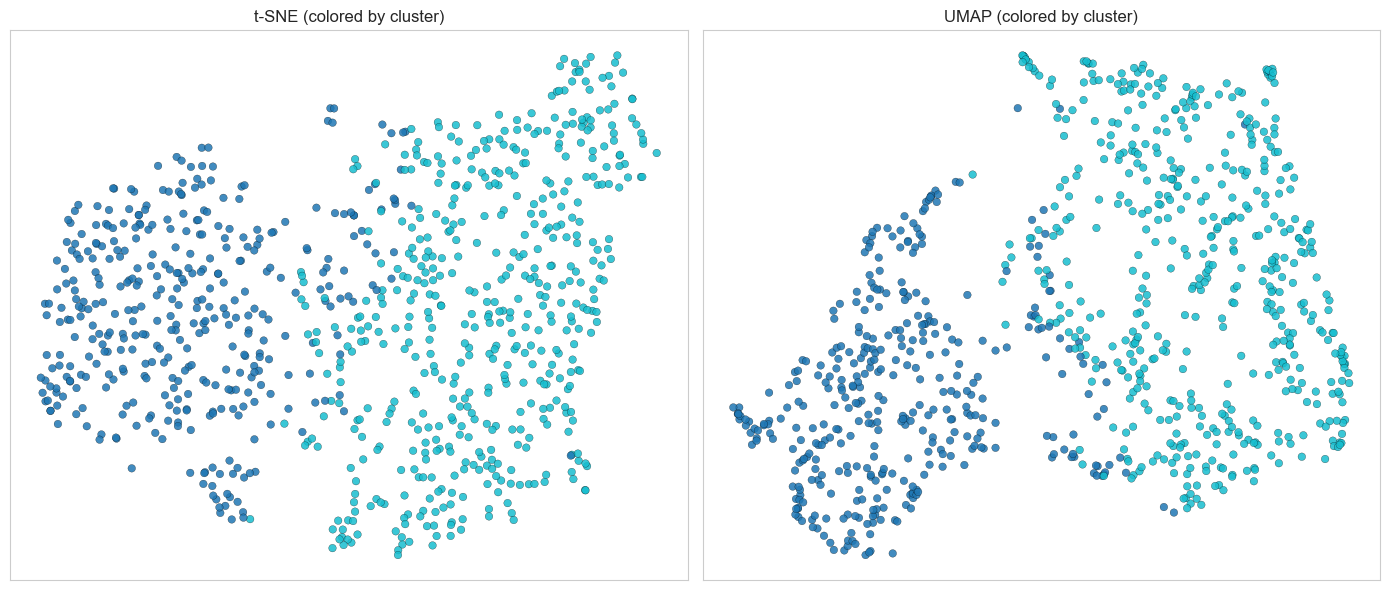

In [45]:
tsne_2d = TSNE(n_components=2, perplexity=30, learning_rate="auto",
               init="pca", random_state=RNG).fit_transform(X)
umap_2d = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean",
                    random_state=RNG).fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, title in [(axes[0], tsne_2d, "t-SNE"), (axes[1], umap_2d, "UMAP")]:
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=df["cluster"],
                    cmap="tab10", s=30, alpha=0.85, edgecolors="k", linewidths=0.2)
    ax.set_title(f"{title} (colored by cluster)")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

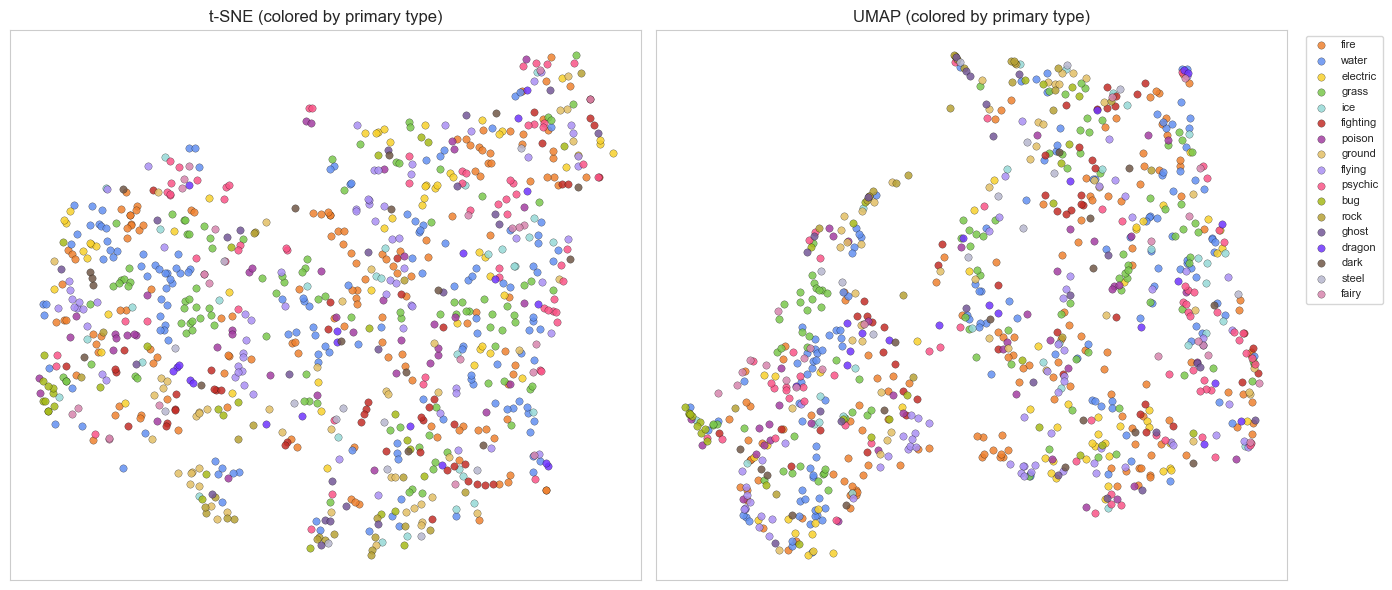

In [46]:
type_colors = {
    "fire": "#EE8130", "water": "#6390F0", "electric": "#F7D02C",
    "grass": "#7AC74C", "ice": "#96D9D6", "fighting": "#C22E28",
    "poison": "#A33EA1", "ground": "#E2BF65", "flying": "#A98FF3",
    "psychic": "#F95587", "bug": "#A6B91A", "rock": "#B6A136",
    "ghost": "#735797", "dragon": "#6F35FC", "dark": "#705746",
    "steel": "#B7B7CE", "fairy": "#D685AD",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, title in [(axes[0], tsne_2d, "t-SNE"), (axes[1], umap_2d, "UMAP")]:
    for t, color in type_colors.items():
        mask = (primary_type == t).to_numpy()
        if mask.any():
            ax.scatter(coords[mask, 0], coords[mask, 1], c=color,
                       label=t, s=28, alpha=0.85, edgecolors="k", linewidths=0.2)
    ax.set_title(f"{title} (colored by primary type)")
    ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## 4. Outlier Detection

Three methods, then we compare their agreement and inspect Pokemon flagged by all three.

- **Local Outlier Factor (LOF)** — local density vs. neighborhood.
- **Isolation Forest** — random tree path length.
- **HDBSCAN noise points** — points the density-based clusterer can't assign.

In [47]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_pred = lof.fit_predict(X)            # -1 = outlier
lof_score = -lof.negative_outlier_factor_

iso = IsolationForest(contamination=0.05, random_state=RNG).fit(X)
iso_pred = iso.predict(X)                # -1 = outlier
iso_score = -iso.score_samples(X)

hdb = hdbscan.HDBSCAN(min_cluster_size=10, metric="euclidean").fit(X)
hdb_outlier = (hdb.labels_ == -1)

df["lof_outlier"] = lof_pred == -1
df["iso_outlier"] = iso_pred == -1
df["hdb_outlier"] = hdb_outlier
df["outlier_votes"] = df[["lof_outlier", "iso_outlier", "hdb_outlier"]].sum(axis=1)

print("Counts:")
print(df[["lof_outlier", "iso_outlier", "hdb_outlier"]].sum())
print("\nVote distribution:", df["outlier_votes"].value_counts().sort_index().to_dict())

Counts:
lof_outlier     45
iso_outlier     45
hdb_outlier    898
dtype: int64

Vote distribution: {1: 817, 2: 72, 3: 9}


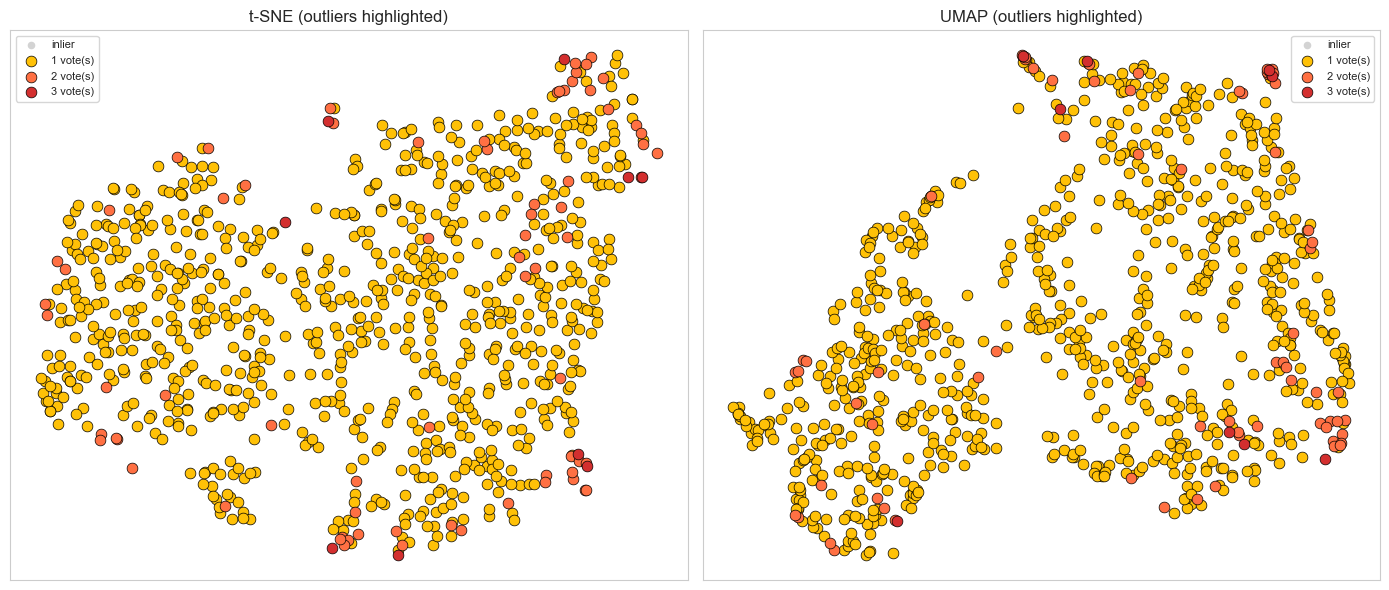

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, title in [(axes[0], tsne_2d, "t-SNE"), (axes[1], umap_2d, "UMAP")]:
    inlier = df["outlier_votes"] == 0
    ax.scatter(coords[inlier, 0], coords[inlier, 1], c="lightgray", s=20, label="inlier")
    for v, color in [(1, "#FFC107"), (2, "#FF7043"), (3, "#D32F2F")]:
        m = (df["outlier_votes"] == v).to_numpy()
        if m.any():
            ax.scatter(coords[m, 0], coords[m, 1], c=color, s=60,
                       edgecolors="k", linewidths=0.5, label=f"{v} vote(s)")
    ax.set_title(f"{title} (outliers highlighted)")
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [49]:
top = df.sort_values("outlier_votes", ascending=False).head(15)
top[["name", "primary_type", "HP", "attack", "defense",
     "sp. attack", "sp. defense", "speed", "outlier_votes"]]

,name,primary_type,HP,attack,defense,sp. attack,sp. defense,speed,outlier_votes
794,Pheromosa,fighting,71,137,37,137,37,151,3
804,Stakataka,rock,61,131,211,53,101,13,3
805,Blacephalon,fire,53,127,53,151,79,107,3
91,Gastly,poison,30,35,30,100,35,80,3
425,Drifblim,flying,150,80,44,90,54,80,3
212,Shuckle,bug,20,10,230,10,230,5,3
94,Onix,ground,35,45,160,30,45,70,3
889,Eternatus,poison,140,85,95,145,95,130,3
798,Guzzlord,dragon,223,101,53,97,53,43,3
73,Geodude,ground,40,80,100,30,30,20,2


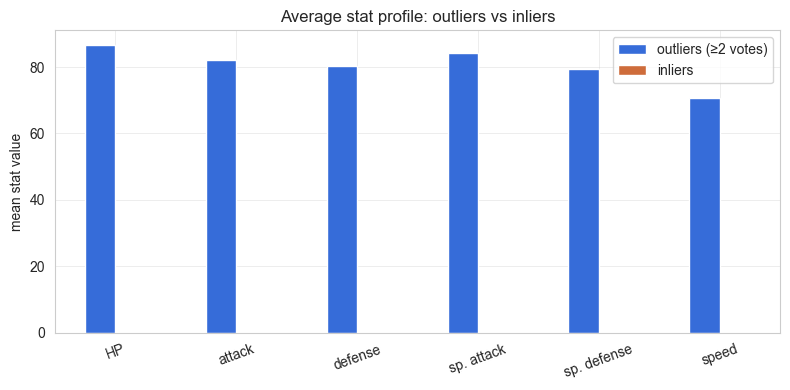

,outliers (≥2 votes),inliers
HP,86.7,NaN
attack,82.1,NaN
defense,80.3,NaN
sp. attack,84.3,NaN
sp. defense,79.3,NaN
speed,70.7,NaN


In [50]:
outlier_means = df[df["outlier_votes"] >= 2][stat_cols].mean()
inlier_means = df[df["outlier_votes"] == 0][stat_cols].mean()
compare = pd.DataFrame({"outliers (≥2 votes)": outlier_means, "inliers": inlier_means})

fig, ax = plt.subplots(figsize=(8, 4))
compare.plot(kind="bar", ax=ax)
ax.set_title("Average stat profile: outliers vs inliers")
ax.set_ylabel("mean stat value")
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()
compare.round(1)

## 5. Discussion & Reflection

**What worked well**
- Mixing **standardized stats** with **type one-hots** gave a feature space where both "power level" (driven by stats) and "flavor" (driven by type) influence distance. The cluster × type heatmap shows clusters are not just type-driven — within a type, weak and strong evolutions land in different clusters.
- **Silhouette sweep** gave an objective, reproducible way to pick `k` rather than guessing. Both KMeans and Ward agreed on the rough region.
- **t-SNE and UMAP** produced compatible 2D layouts — clusters that are tight in feature space stay tight in both projections, which is a good sanity check.
- **Voting across 3 outlier methods** is more robust than any single method. The Pokemon flagged by ≥2 methods are the genuinely unusual ones (legendaries, Shuckle-style extreme stat distributions, etc.).

**Challenges**
- Choosing the **stat-vs-type weight ratio** is subjective. With `w_stats=1.5, w_types=1.0` the clusters reflect both, but other ratios produce noticeably different partitions.
- Many Pokemon are **dual-typed**, but we collapse to a single "primary type" for plotting — that loses information visually even though the full type vector goes into the distance.
- Silhouette favors **convex, equal-sized clusters**; Pokemon evolution lines form chains, not blobs, so silhouette may underrate hierarchical / density structure.
- Image thumbnails (mentioned in the prompt as a possible feature) were **not used** — extracting useful embeddings would need a CNN and is out of scope here.

**With more time**
- Add **image-based features** via a pretrained CNN (e.g. CLIP or ResNet) and concatenate with the current feature vector.
- Use **Gower distance** so type (categorical) and stats (numeric) are mixed without manual weighting.
- Try **HDBSCAN as the primary clusterer** (not just for outliers) and compare its variable-density clusters against KMeans/Ward.
- Run a small **ablation**: cluster with stats-only, types-only, and combined to quantify how much each contributes.